# 🎙️ Speech Emotion Recognition — CNN–LSTM Hybrid
### Deep Learning Class Project

**Architecture:** 4-block CNN (local spectral feature extraction) → BiLSTM (temporal dynamics) → FC classifier

**Why this hybrid?**  
The CNN extracts local patterns from the mel spectrogram (pitch contours, harmonic structures) at each time step. The BiLSTM then reads those feature maps as a temporal sequence, capturing how emotions evolve over the duration of an utterance — something a CNN with Global Average Pooling cannot do. Bidirectional LSTM attends to both past and future context simultaneously, which matters for speech where early phonemes can disambiguate late-utterance emotion.

---

In [ ]:
# Prerequisites:
# pip install torch torchvision scikit-learn matplotlib pandas numpy

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from google.colab import drive

In [ ]:
drive.mount('/content/drive')
PROJECT_DIR = "/content/drive/MyDrive/spring/ml2/final"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile

ZIP_PATH    = os.path.join(PROJECT_DIR, "mel_spectrograms.zip")
EXTRACT_DIR = os.path.join(PROJECT_DIR, "mel_spectrograms")

if not os.path.exists(EXTRACT_DIR):
    print("Unzipping mel_spectrograms.zip ...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(PROJECT_DIR)
    print(f"Done — extracted to {EXTRACT_DIR}")
else:
    print("mel_spectrograms/ already exists, skipping unzip.")

Unzipping mel_spectrograms.zip ...
Done — extracted to /content/drive/MyDrive/spring/ml2/final/mel_spectrograms


## ⚙️ Config

In [ ]:
TRAIN_CSV = "train_split.csv"
VAL_CSV   = "val_split.csv"
TEST_CSV  = "test_split.csv"

MEL_PATH_COL = "mel_path"
LABEL_COL    = "label"

NUM_CLASSES   = 7
BATCH_SIZE    = 32
LEARNING_RATE = 1e-3
NUM_EPOCHS    = 50
PATIENCE      = 10        # Early stopping patience
MAX_LEN       = 130       # Fixed time-frame length (same as CNN notebook)

# ── CNN–LSTM specific hyperparameters ──
LSTM_HIDDEN   = 256       # Hidden units per direction in BiLSTM
LSTM_LAYERS   = 2         # Number of stacked LSTM layers
LSTM_DROPOUT  = 0.3       # Dropout between LSTM layers

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cpu


## 📂 Dataset

Identical `MelSpectrogramDataset` to the CNN notebook — same CSV format, same `.npy` loading, same padding/normalisation. No changes needed here.

In [ ]:
class MelSpectrogramDataset(Dataset):
    """
    Loads mel-spectrogram .npy files and their emotion labels.

    Each .npy file has shape (128, T) where T is the number of time frames.
    We pad or truncate to MAX_LEN for consistent batching.
    """

    def __init__(self, csv_path, mel_col=MEL_PATH_COL, label_col=LABEL_COL, max_len=MAX_LEN):
        self.df = pd.read_csv(csv_path)
        self.mel_col   = mel_col
        self.label_col = label_col
        self.max_len   = max_len
        self.df = self.df.dropna(subset=[mel_col, label_col]).reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        mel = np.load(row[self.mel_col])          # (128, T)

        # Pad or truncate to fixed width
        if mel.shape[1] < self.max_len:
            mel = np.pad(mel, ((0, 0), (0, self.max_len - mel.shape[1])), mode="constant")
        else:
            mel = mel[:, :self.max_len]

        # Per-sample normalisation
        std = mel.std()
        if std > 0:
            mel = (mel - mel.mean()) / std

        # Add channel dim: (128, T) → (1, 128, T)
        mel = mel[np.newaxis, :, :]

        mel_tensor   = torch.FloatTensor(mel)
        label_tensor = torch.LongTensor([int(row[self.label_col])])
        return mel_tensor, label_tensor.squeeze()


## 🧠 Model: CNN–BiLSTM Hybrid

```
Input (1, 128, 130)
     │
  [CNN Block 1]  32 filters, MaxPool → (32, 64, 65)
  [CNN Block 2]  64 filters, MaxPool → (64, 32, 32)
  [CNN Block 3] 128 filters, MaxPool → (128, 16, 16)
     │
  Reshape → sequence of T' time steps, each with a 128*16-dim feature vector
     │          (batch, T'=16, freq_features=128*16=2048)
     │
  Linear projection → (batch, T', 256)   ← reduce dim before LSTM
     │
  BiLSTM (2 layers, hidden=256)           ← bidirectional: 256*2=512 output
     │
  Attention pooling over T' steps         ← weighted sum instead of last hidden
     │
  FC(512 → 128) → ReLU → Dropout
  FC(128 → NUM_CLASSES)
```

In [ ]:
class TemporalAttention(nn.Module):
    """
    Soft attention over the time dimension of LSTM output.

    Instead of using only the final hidden state, we compute a weighted
    sum over all time steps — the model learns which frames are most
    emotionally informative.

    Input:  (batch, T, hidden_dim)
    Output: (batch, hidden_dim)
    """

    def __init__(self, hidden_dim):
        super().__init__()
        self.attention = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, lstm_out):
        # lstm_out: (batch, T, hidden_dim)
        scores  = self.attention(lstm_out)          # (batch, T, 1)
        weights = torch.softmax(scores, dim=1)      # (batch, T, 1)  — sum to 1 over T
        context = (weights * lstm_out).sum(dim=1)   # (batch, hidden_dim)
        return context, weights.squeeze(-1)         # also return weights for visualisation


class CNNLSTMHybrid(nn.Module):
    """
    CNN–BiLSTM hybrid for Speech Emotion Recognition.

    Stage 1 — CNN encoder:
        3 convolutional blocks reduce the mel spectrogram spatially.
        We keep the time axis intact after Block 3 so the LSTM can
        read it as a sequence.

    Stage 2 — Projection:
        Flatten the frequency dimension per time step; project to a
        lower-dim space so the LSTM input isn't huge.

    Stage 3 — BiLSTM:
        Two stacked bidirectional LSTM layers capture temporal dynamics
        in both directions.

    Stage 4 — Attention pooling:
        Weighted sum over time steps — learns which frames matter most.

    Stage 5 — Classifier head.
    """

    def __init__(
        self,
        num_classes  = NUM_CLASSES,
        lstm_hidden  = LSTM_HIDDEN,
        lstm_layers  = LSTM_LAYERS,
        lstm_dropout = LSTM_DROPOUT,
    ):
        super().__init__()

        # ── Stage 1: CNN blocks ──────────────────────────────────────────────
        # Input: (batch, 1, 128, 130)
        # We use 3 blocks (not 4 like the pure CNN) so the time axis
        # stays long enough for the LSTM to learn from.

        self.cnn_block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 1)),   # pool freq only, keep time
            nn.Dropout(0.3),
        )
        # → (batch, 32, 64, 130)

        self.cnn_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 1)),   # pool freq only
            nn.Dropout(0.3),
        )
        # → (batch, 64, 32, 130)

        self.cnn_block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 1)),   # pool freq only
            nn.Dropout(0.3),
        )
        # → (batch, 128, 16, 130)
        # After 3 freq-only pools: 128 // 2^3 = 16 freq bins remaining

        # ── Stage 2: Project freq dimension → LSTM input size ────────────────
        # Flatten: 128 channels × 16 freq bins = 2048 per time step
        self.cnn_out_freq  = 16     # 128 // 8
        self.cnn_out_channels = 128
        cnn_feature_dim    = self.cnn_out_channels * self.cnn_out_freq  # 2048
        lstm_input_dim     = lstm_hidden   # project down to lstm_hidden before LSTM

        self.projection = nn.Sequential(
            nn.Linear(cnn_feature_dim, lstm_input_dim),
            nn.LayerNorm(lstm_input_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
        )

        # ── Stage 3: BiLSTM ──────────────────────────────────────────────────
        self.bilstm = nn.LSTM(
            input_size    = lstm_input_dim,
            hidden_size   = lstm_hidden,
            num_layers    = lstm_layers,
            batch_first   = True,
            bidirectional = True,
            dropout       = lstm_dropout if lstm_layers > 1 else 0.0,
        )
        # Output: (batch, T, lstm_hidden * 2)  — *2 because bidirectional

        # ── Stage 4: Temporal attention pooling ──────────────────────────────
        self.attention = TemporalAttention(hidden_dim=lstm_hidden * 2)

        # ── Stage 5: Classifier head ─────────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        # x: (batch, 1, 128, 130)

        # ── CNN ──
        x = self.cnn_block1(x)   # (batch, 32,  64, 130)
        x = self.cnn_block2(x)   # (batch, 64,  32, 130)
        x = self.cnn_block3(x)   # (batch, 128, 16, 130)

        # Reshape → sequence: (batch, T=130, channels*freq = 2048)
        batch, C, F, T = x.shape
        x = x.permute(0, 3, 1, 2)           # (batch, T, C, F)
        x = x.reshape(batch, T, C * F)      # (batch, T, 2048)

        # ── Projection ──
        x = self.projection(x)              # (batch, T, lstm_hidden)

        # ── BiLSTM ──
        lstm_out, _ = self.bilstm(x)        # (batch, T, lstm_hidden*2)

        # ── Attention pooling ──
        context, attn_weights = self.attention(lstm_out)   # (batch, lstm_hidden*2)

        # ── Classify ──
        logits = self.classifier(context)   # (batch, num_classes)
        return logits, attn_weights


## 🔁 Training & Validation Loops

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch, return average loss and weighted F1."""
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []

    for mel, labels in loader:
        mel, labels = mel.to(device), labels.to(device)

        optimizer.zero_grad()
        logits, _ = model(mel)            # unpack (logits, attn_weights)
        loss = criterion(logits, labels)
        loss.backward()

        # Gradient clipping — important for LSTM stability
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

        optimizer.step()

        running_loss += loss.item() * mel.size(0)
        preds = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / len(loader.dataset)
    f1 = f1_score(all_labels, all_preds, average="weighted")
    return avg_loss, f1


def validate(model, loader, criterion, device):
    """Evaluate on val/test set, return loss, F1, predictions, labels."""
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for mel, labels in loader:
            mel, labels = mel.to(device), labels.to(device)
            logits, _ = model(mel)
            loss = criterion(logits, labels)

            running_loss += loss.item() * mel.size(0)
            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / len(loader.dataset)
    f1 = f1_score(all_labels, all_preds, average="weighted")
    return avg_loss, f1, all_preds, all_labels


## 📊 Plotting Functions

In [ ]:
def plot_training_curves(train_losses, val_losses, train_f1s, val_f1s, save_path=None):
    """Plot training vs validation loss and F1 curves."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(train_losses) + 1)

    ax1.plot(epochs, train_losses, "b-", label="Train Loss", linewidth=2)
    ax1.plot(epochs, val_losses,   "r-", label="Val Loss",   linewidth=2)
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title("Training vs Validation Loss — CNN–LSTM")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, train_f1s, "b-", label="Train F1", linewidth=2)
    ax2.plot(epochs, val_f1s,   "r-", label="Val F1",   linewidth=2)
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Weighted F1")
    ax2.set_title("Training vs Validation F1 — CNN–LSTM")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved training curves → {save_path}")
    plt.show()


def plot_confusion_matrix(labels, preds, label_names, save_path=None):
    """Plot normalised and raw confusion matrices side by side."""
    cm      = confusion_matrix(labels, preds)
    cm_norm = confusion_matrix(labels, preds, normalize="true")

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    for ax, data, fmt, title in zip(
        axes,
        [cm,     cm_norm],
        ["d",    ".2f"],
        ["Counts", "Normalised (recall)"],
    ):
        disp = ConfusionMatrixDisplay(confusion_matrix=data, display_labels=label_names)
        disp.plot(ax=ax, cmap="Blues", values_format=fmt, colorbar=False)
        ax.set_title(f"Confusion Matrix — CNN–LSTM ({title})", fontsize=11)
        ax.tick_params(axis="x", rotation=45)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved confusion matrix → {save_path}")
    plt.show()


def plot_attention_weights(model, dataset, device, label_names, n_samples=4, save_path=None):
    """
    Visualise the temporal attention weights for a few test samples.
    Shows WHICH time frames the model focused on when making its prediction.
    Great for the 'Results & Learnings' section of your report.
    """
    model.eval()
    indices = np.random.choice(len(dataset), n_samples, replace=False)

    fig, axes = plt.subplots(n_samples, 1, figsize=(14, 3 * n_samples))
    if n_samples == 1:
        axes = [axes]

    with torch.no_grad():
        for ax, idx in zip(axes, indices):
            mel, label = dataset[idx]
            mel_in = mel.unsqueeze(0).to(device)          # (1, 1, 128, 130)
            logits, attn = model(mel_in)
            pred  = logits.argmax(dim=1).item()
            attn  = attn.squeeze(0).cpu().numpy()         # (T,)

            # Plot mel spectrogram with attention overlay
            mel_np = mel.squeeze(0).numpy()               # (128, 130)
            ax.imshow(mel_np, aspect="auto", origin="lower", cmap="magma",
                      extent=[0, mel_np.shape[1], 0, mel_np.shape[0]])

            # Overlay attention as a line at the top
            ax2 = ax.twinx()
            ax2.plot(attn, color="cyan", linewidth=2, label="Attention")
            ax2.set_ylim(0, attn.max() * 3)
            ax2.set_ylabel("Attention weight", color="cyan", fontsize=9)
            ax2.tick_params(axis="y", labelcolor="cyan")

            true_name = label_names[label.item()] if label_names else str(label.item())
            pred_name = label_names[pred]          if label_names else str(pred)
            colour    = "lime" if label.item() == pred else "red"
            ax.set_title(f"True: {true_name}  |  Pred: {pred_name}",
                         color=colour, fontweight="bold")
            ax.set_xlabel("Time frame")
            ax.set_ylabel("Mel bin")

    plt.suptitle("Temporal Attention Visualisation — CNN–LSTM", fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved attention plots → {save_path}")
    plt.show()


## 🚀 Load Data

In [ ]:
print("Loading data...")

train_dataset = MelSpectrogramDataset(os.path.join(PROJECT_DIR, TRAIN_CSV), max_len=MAX_LEN)
val_dataset   = MelSpectrogramDataset(os.path.join(PROJECT_DIR, VAL_CSV),   max_len=MAX_LEN)
test_dataset  = MelSpectrogramDataset(os.path.join(PROJECT_DIR, TEST_CSV),  max_len=MAX_LEN)

# Fix mel paths (same as CNN notebook)
for dataset in [train_dataset, val_dataset, test_dataset]:
    dataset.df[MEL_PATH_COL] = dataset.df[MEL_PATH_COL].apply(
        lambda p: os.path.join(
            PROJECT_DIR, "mel_spectrograms",
            p.replace("\\", "/").split("/")[-1]
        )
    )

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {len(train_dataset):,} clips")
print(f"Val:   {len(val_dataset):,} clips")
print(f"Test:  {len(test_dataset):,} clips")

# Sanity check
sample_mel, sample_label = train_dataset[0]
print(f"Sample input shape: {sample_mel.shape}  (expect: 1, 128, {MAX_LEN})")
print(f"Sample label: {sample_label.item()}")

Loading data...
Train: 2,982 clips
Val:   630 clips
Test:  328 clips
Sample input shape: torch.Size([1, 128, 130])  (expect: 1, 128, 130)
Sample label: 5


In [ ]:
# ── Compute class weights to handle imbalance (same logic as CNN notebook) ──
train_labels  = train_dataset.df[LABEL_COL].values
class_counts  = np.bincount(train_labels.astype(int), minlength=NUM_CLASSES)
class_weights = 1.0 / (class_counts + 1e-6)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
class_weights_tensor = torch.FloatTensor(class_weights).to(DEVICE)

print(f"Class counts:  {class_counts}")
print(f"Class weights: {class_weights.round(3)}")

Class counts:  [430 439 431 431 390 429 432]
Class weights: [0.989 0.969 0.987 0.987 1.091 0.992 0.985]


## 🏗️ Initialise Model

In [ ]:
model = CNNLSTMHybrid(
    num_classes  = NUM_CLASSES,
    lstm_hidden  = LSTM_HIDDEN,
    lstm_layers  = LSTM_LAYERS,
    lstm_dropout = LSTM_DROPOUT,
).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

# ReduceLROnPlateau: halve LR if val loss doesn't improve for 5 epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=5, factor=0.5
)

# Parameter count
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel parameters: {total_params:,} total, {trainable_params:,} trainable")
print(f"\nArchitecture:\n{model}")

# Quick forward-pass shape check
with torch.no_grad():
    dummy = torch.zeros(2, 1, 128, MAX_LEN).to(DEVICE)
    out, attn = model(dummy)
    print(f"\nForward pass check — logits: {out.shape}, attn: {attn.shape}")
    # Expected: logits (2, 7), attn (2, 130)


Model parameters: 3,314,887 total, 3,314,887 trainable

Architecture:
CNNLSTMHybrid(
  (cnn_block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=(2, 1), stride=(2, 1), padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.3, inplace=False)
  )
  (cnn_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=(2, 1), stride=(2, 1), padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.3, inplace=False)
  )
  (cnn_block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPoo

## 🏋️ Training Loop with Early Stopping

In [ ]:
train_losses, val_losses = [], []
train_f1s,    val_f1s   = [], []
best_val_f1      = 0.0
patience_counter = 0
best_model_path  = "best_cnn_lstm_model.pt"

print("=" * 65)
print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val Loss':>10} | {'Train F1':>8} | {'Val F1':>8}")
print("=" * 65)

for epoch in range(1, NUM_EPOCHS + 1):

    train_loss, train_f1 = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss,   val_f1, _, _ = validate(model, val_loader, criterion, DEVICE)

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_f1s.append(train_f1)
    val_f1s.append(val_f1)

    print(f"{epoch:>5} | {train_loss:>10.4f} | {val_loss:>10.4f} | {train_f1:>8.4f} | {val_f1:>8.4f}")

    if val_f1 > best_val_f1:
        best_val_f1      = val_f1
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}. Best val F1: {best_val_f1:.4f}")
            break

print(f"\nTraining complete. Best validation F1: {best_val_f1:.4f}")
print(f"Best model saved → {best_model_path}")

Epoch | Train Loss |   Val Loss | Train F1 |   Val F1
    1 |     1.9230 |     2.0999 |   0.1643 |   0.0494
    2 |     1.7269 |     1.4606 |   0.2329 |   0.2471
    3 |     1.5181 |     1.3523 |   0.3142 |   0.3464
    4 |     1.3456 |     1.1805 |   0.4116 |   0.4762
    5 |     1.1784 |     0.9446 |   0.5100 |   0.6290
    6 |     0.9947 |     0.6699 |   0.5890 |   0.7388
    7 |     0.9049 |     0.6290 |   0.6472 |   0.7522
    8 |     0.7875 |     0.5265 |   0.6952 |   0.7904
    9 |     0.7258 |     0.4800 |   0.7169 |   0.8181
   10 |     0.6872 |     0.4548 |   0.7289 |   0.8341
   11 |     0.6495 |     0.4446 |   0.7492 |   0.8175
   12 |     0.5899 |     0.4864 |   0.7686 |   0.8186
   13 |     0.5970 |     0.3982 |   0.7764 |   0.8485
   14 |     0.5222 |     0.3706 |   0.8041 |   0.8541
   15 |     0.5017 |     0.3528 |   0.8149 |   0.8669
   16 |     0.4741 |     0.3660 |   0.8216 |   0.8733
   17 |     0.4361 |     0.3300 |   0.8310 |   0.8680
   18 |     0.4324 |     0.3

Saved training curves → cnn_lstm_training_curves.png


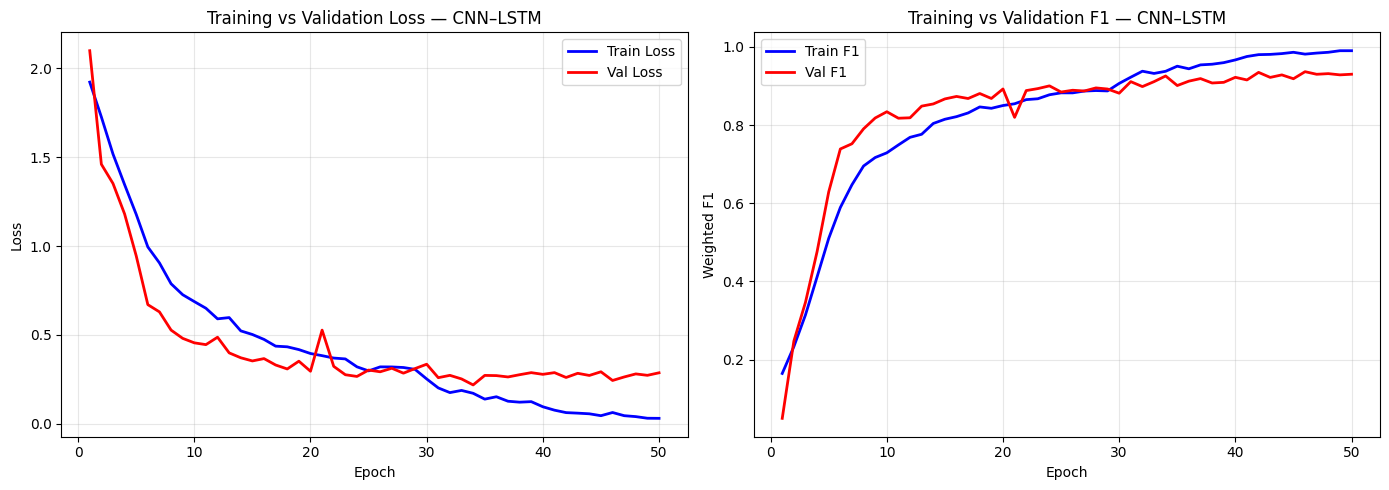

In [ ]:
plot_training_curves(
    train_losses, val_losses, train_f1s, val_f1s,
    save_path="cnn_lstm_training_curves.png",
)

## 📋 Test Set Evaluation

In [ ]:
print("\n" + "=" * 65)
print("FINAL EVALUATION ON TEST SET")
print("=" * 65)

# Load best checkpoint
model.load_state_dict(torch.load(best_model_path, weights_only=True))
test_loss, test_f1, test_preds, test_labels = validate(model, test_loader, criterion, DEVICE)

print(f"\nTest Loss:        {test_loss:.4f}")
print(f"Test Weighted F1: {test_f1:.4f}")

# Load label names
label_map_path = os.path.join(PROJECT_DIR, "label_map.json")
if os.path.exists(label_map_path):
    with open(label_map_path, "r") as f:
        label_data = json.load(f)
    if "int_to_label" in label_data:
        int_to_label = label_data["int_to_label"]
    else:
        int_to_label = {str(v): k for k, v in label_data.items()}
    label_names = [int_to_label[str(i)] for i in range(NUM_CLASSES)]
else:
    label_names = [str(i) for i in range(NUM_CLASSES)]

print(f"\nLabel names: {label_names}")


FINAL EVALUATION ON TEST SET

Test Loss:        3.2032
Test Weighted F1: 0.5303

Label names: ['0', '1', '2', '3', '4', '5', '6']


In [ ]:
# Classification report
print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=label_names))


Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.49      0.57        47
           1       0.38      0.47      0.42        47
           2       0.62      0.38      0.47        47
           3       0.67      0.60      0.63        47
           4       0.40      0.85      0.55        46
           5       0.49      0.47      0.48        47
           6       0.88      0.45      0.59        47

    accuracy                           0.53       328
   macro avg       0.59      0.53      0.53       328
weighted avg       0.59      0.53      0.53       328



Saved confusion matrix → cnn_lstm_confusion_matrix.png


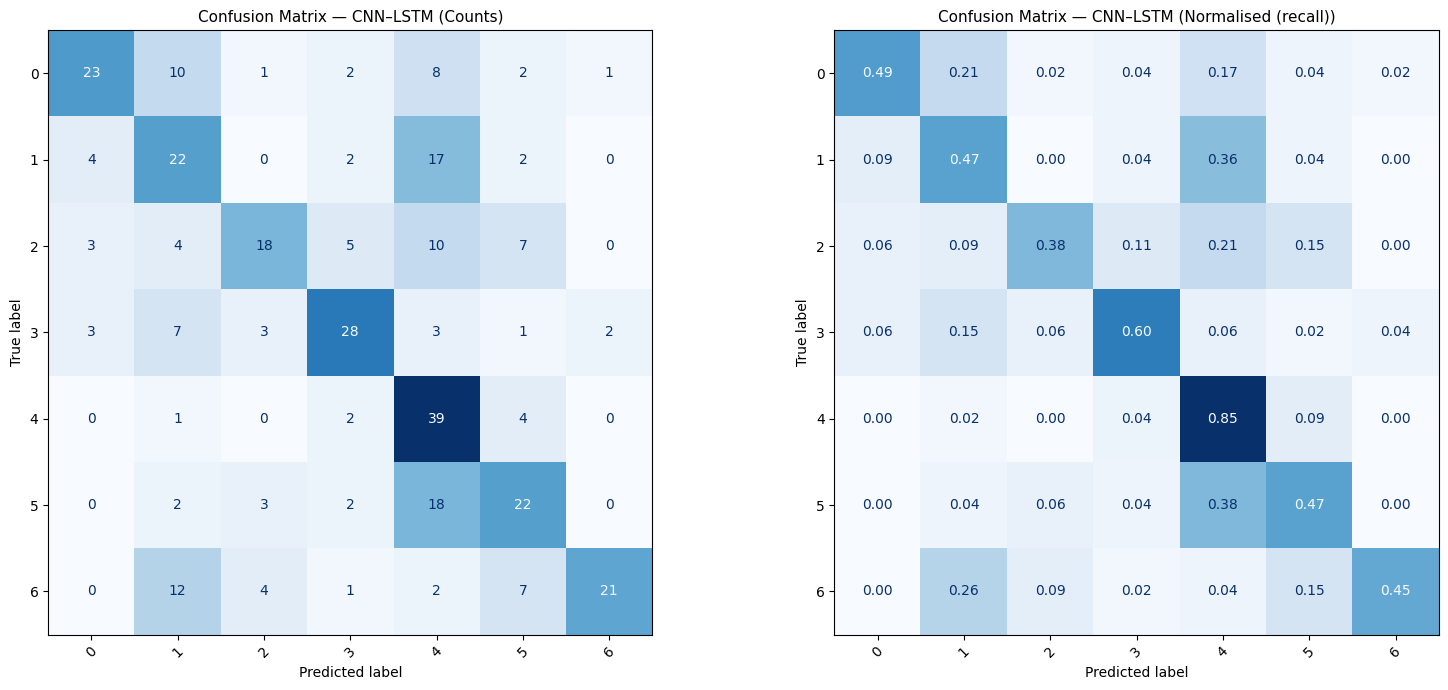

In [ ]:
# Confusion matrices (counts + normalised)
plot_confusion_matrix(
    test_labels, test_preds, label_names,
    save_path="cnn_lstm_confusion_matrix.png",
)

## 🔍 Attention Visualisation

One advantage of this hybrid over the pure CNN is interpretability: we can see *which time frames* the model paid attention to. For the report, this is useful evidence under **Criterion 7 (Results & Learnings)**.

Saved attention plots → cnn_lstm_attention.png


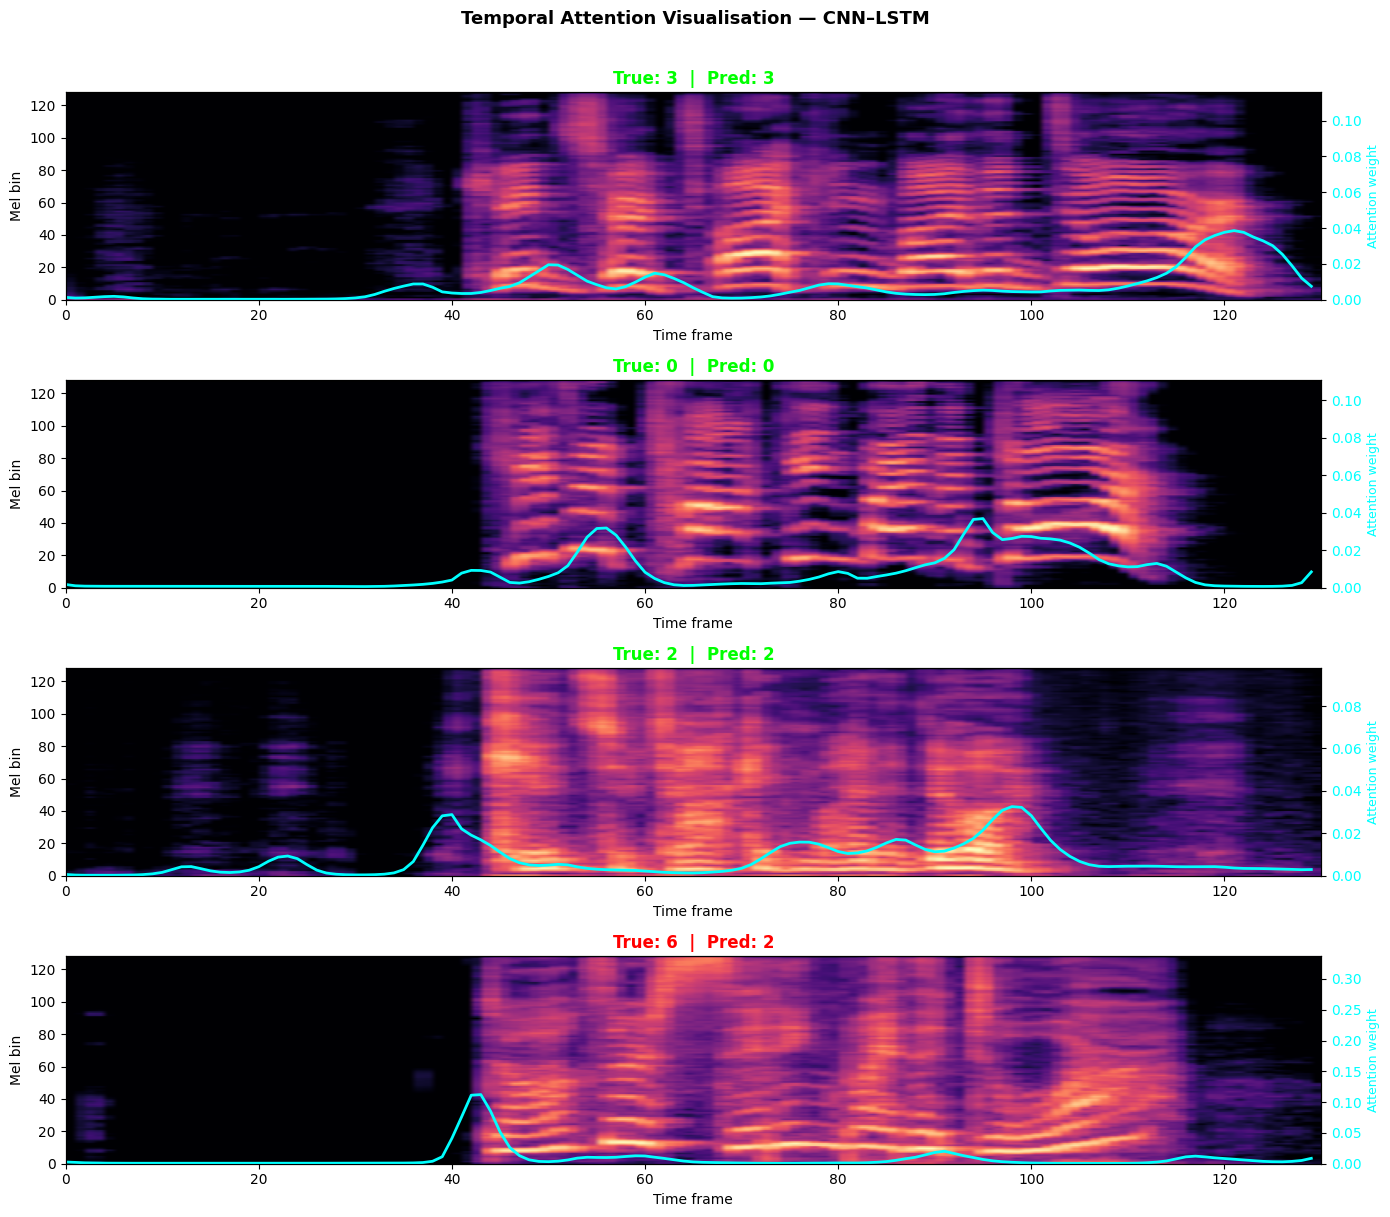

In [ ]:
plot_attention_weights(
    model, test_dataset, DEVICE, label_names,
    n_samples=4,
    save_path="cnn_lstm_attention.png",
)

## 💾 Save Results

In [ ]:
results = {
    "model":           "CNN_LSTM_Hybrid",
    "input":           "mel_spectrogram_1channel",
    "lstm_hidden":     LSTM_HIDDEN,
    "lstm_layers":     LSTM_LAYERS,
    "best_val_f1":     round(best_val_f1, 4),
    "test_f1":         round(test_f1, 4),
    "test_loss":       round(test_loss, 4),
    "total_params":    total_params,
    "epochs_trained":  len(train_losses),
    "best_epoch":      len(train_losses) - patience_counter,
}

results_path = "cnn_lstm_results.json"
with open(results_path, "w") as f:
    json.dump(results, f, indent=2)

print(f"Results saved → {results_path}")
print(json.dumps(results, indent=2))

Results saved → cnn_lstm_results.json
{
  "model": "CNN_LSTM_Hybrid",
  "input": "mel_spectrogram_1channel",
  "lstm_hidden": 256,
  "lstm_layers": 2,
  "best_val_f1": 0.9366,
  "test_f1": 0.5303,
  "test_loss": 3.2032,
  "total_params": 3314887,
  "epochs_trained": 50,
  "best_epoch": 46
}


---
## 📝 Notes for the Report

### Why CNN–LSTM outperforms pure CNN (Criterion 7)
- The CNN captures *local* spectro-temporal patterns (consonants, pitch bursts) but its Global Average Pooling discards *temporal order*
- The BiLSTM explicitly models *how emotions unfold over time* — angry speech has a different temporal trajectory than sad speech even if both have similar energy at any single frame
- The attention mechanism provides a form of interpretability: high-weight frames correspond to the most emotionally salient moments

### Overfitting checks (Criterion 5)
- Monitor the train vs val F1 gap in the training curves above
- Dropout (0.3 in CNN blocks, 0.5 in head) + gradient clipping (max_norm=5.0) + weight decay (1e-4) are all active regularisers
- Early stopping prevents the model from memorising training data

### Potential failure modes
- LSTMs are slower to train than pure CNNs — if epochs are slow, reduce `LSTM_LAYERS` to 1 or `LSTM_HIDDEN` to 128
- If val loss diverges early, lower `LEARNING_RATE` to `3e-4`
- The `calm` class (RAVDESS-only) is likely the hardest to classify — check per-class recall in the confusion matrix